In [5]:
import matplotlib.pyplot as plt
import pandas as pd


# Load and process both datasets
def load_data(filename, metric_suffix):
    df = pd.read_csv(filename)
    df = df.filter(regex=f'{metric_suffix}$', axis=1)
    df = df.rename(columns=lambda x: x.split('_')[2] if metric_suffix in x else x)


    
    df = df.rename(columns=lambda x: f'Experiment-A' if x.startswith('experiment01') else x)
        # Rename experiment02 to experiment01, experiment03 to experiment02, etc.
    df = df.rename(columns=lambda x: f'experiment{int(x[-1:]) - 1}' if x.startswith('experiment') else x)
    return df.agg(['median', 'std']).T

# Load both metrics
winrates = load_data('data/eval_winrates_all.csv', 'eval_win_rate')
rewards = load_data('data/eval_rewards_all.csv', 'eval_average_episode_rewards')

# Combine into single dataframe with multi-level columns
df = pd.concat({'Win Rate': winrates, 'Episode Rewards': rewards}, axis=1)
df = df.sort_index()


# Rename baseline to Baseline, experiment01 --> Experiment 1, etc
df.index = df.index.map(lambda x: 'Baseline' if x == 'baseline' else f'Experiment {x[-1:]}' if x.startswith('experiment') else x)


df

Win Rate           Episode Rewards          
                median       std          median       std
Experiment-A  0.757812  0.052066       20.140239  0.418130
Baseline      0.617188  0.054847       19.573891  0.494239
Experiment 1  0.773438  0.072706       18.790361  0.426144
Experiment 2  0.500000  0.077147       17.096077  0.462901
Experiment 3  0.765625  0.053318       18.938670  0.262706

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define unified color scheme for all experiments
def get_experiment_colors():
    """
    Generate a consistent color palette for experiments using a modern gradient.
    Colors are chosen to be highly differentiable and visually appealing.
    """
    # Modern gradient: deep navy → vibrant teal → warm coral → rich purple → golden amber
    colors = [
        '#2C3E50',  # Deep navy blue (Baseline)
        "#1680A0",  # Vibrant teal (Experiment 1)
        '#8E44AD',  # Rich purple (Experiment 3)
        '#E74C3C',  # Warm coral red (Experiment 2)
        '#F39C12',  # Golden amber (Experiment 4)
    ]
    return colors

# Get the color palette
EXPERIMENT_COLORS = get_experiment_colors()

print("Unified color scheme loaded!")

Unified color scheme loaded!


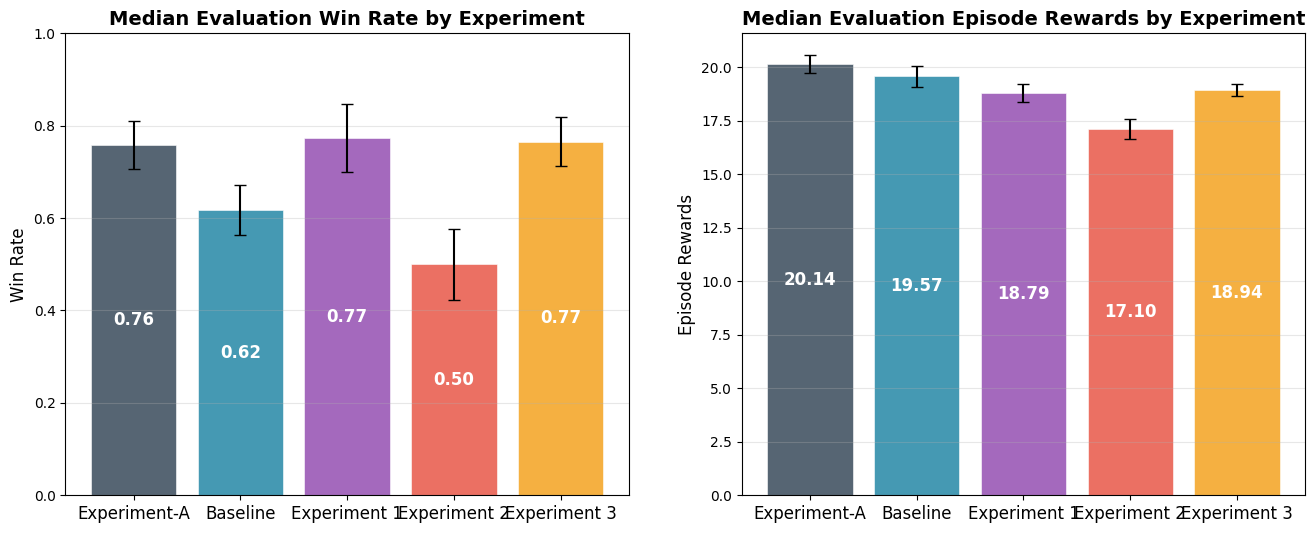

              Win Rate           Episode Rewards          
                median       std          median       std
Experiment-A  0.757812  0.052066       20.140239  0.418130
Baseline      0.617188  0.054847       19.573891  0.494239
Experiment 1  0.773438  0.072706       18.790361  0.426144
Experiment 2  0.500000  0.077147       17.096077  0.462901
Experiment 3  0.765625  0.053318       18.938670  0.262706


In [ ]:
# Plot both metrics with unified colors
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Get colors for each experiment
experiment_names = df.index.tolist()
colors = [EXPERIMENT_COLORS[i % len(EXPERIMENT_COLORS)] for i in range(len(experiment_names))]

for i, metric in enumerate(['Win Rate', 'Episode Rewards']):
    ax = axes[i]
    data = df[metric]
    
    # Plot with error bars using unified colors
    bars = ax.bar(range(len(data)), data['median'], yerr=data['std'], 
                  capsize=4, color=colors, alpha=0.8, 
                  edgecolor='white', linewidth=0.5)
    
    ax.set_title(f'Median Evaluation {metric} by Experiment', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    #set ylim
    ax.set_xticks(range(len(experiment_names)))
    ax.set_xticklabels(experiment_names, rotation=0, ha='center', fontsize=10)
    
    
    # Add values inside the bars using bar_label
    ax.bar_label(bars, labels=[f"{val:.2f}" for val in data['median']], 
                 label_type='center', fontsize=12, fontweight='bold', color='white')
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1)  # Adjusted for better visibility
# plt.tight_layout()
plt.show()

# Create output directory if it doesn't exist
import os
os.makedirs('out', exist_ok=True)

# Save the figure as pdf
fig.savefig('out/evaluation_results_split.pdf', format='pdf', dpi=300, bbox_inches='tight')

# Print the dataframe to console
print(df)

In [11]:
# # Create a combined plot with dual y-axes for win rates and episode rewards
# fig, ax1 = plt.subplots(figsize=(12, 8))

# # Get experiments and colors
# experiments = df.index
# win_rate_means = df[('Win Rate', 'mean')]
# win_rate_stds = df[('Win Rate', 'std')]
# episode_reward_means = df[('Episode Rewards', 'mean')]
# episode_reward_stds = df[('Episode Rewards', 'std')]

# # Use unified colors for each experiment
# experiment_colors = [EXPERIMENT_COLORS[i % len(EXPERIMENT_COLORS)] for i in range(len(experiments))]

# # Plot win rates on left y-axis
# ax1.set_ylabel('Win Rate', fontsize=12, fontweight='bold')
# bars1 = ax1.bar([x - 0.2 for x in range(len(experiments))], win_rate_means, 
#                 yerr=win_rate_stds, capsize=5, width=0.4, 
#                 color=experiment_colors, alpha=0.7, label='Win Rate',
#                 edgecolor='white', linewidth=0.5)
# ax1.set_ylim(0, 1)  # Win rates are typically between 0 and 1

# # Create second y-axis for episode rewards
# ax2 = ax1.twinx()
# ax2.set_ylabel('Episode Rewards', fontsize=12, fontweight='bold')
# # Use slightly darker versions of the same colors for episode rewards
# darker_colors = [plt.matplotlib.colors.to_rgba(c, alpha=0.9) for c in experiment_colors]
# bars2 = ax2.bar([x + 0.2 for x in range(len(experiments))], episode_reward_means,
#                 yerr=episode_reward_stds, capsize=5, width=0.4,
#                 color=darker_colors, alpha=0.7, label='Episode Rewards',
#                 edgecolor='white', linewidth=0.5)

# # Set x-axis labels
# ax1.set_xticks(range(len(experiments)))
# ax1.set_xticklabels(experiments, rotation=45, ha='right')

# # Add title and legends
# plt.title('Experiment Results: Win Rates and Episode Rewards', fontsize=14, fontweight='bold')

# # Create custom legend with experiment names and their colors
# legend_elements = []
# for i, exp_name in enumerate(experiments):
#     legend_elements.append(plt.matplotlib.patches.Patch(color=experiment_colors[i], label=exp_name))

# ax1.legend(handles=legend_elements, loc='upper left', title='Experiments', title_fontsize=10)

# # Add grid for better readability
# ax1.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Save the figure
# fig.savefig('out/evaluation_results_combined.pdf', format='pdf', dpi=300, bbox_inches='tight')


In [ ]:
# Load and plot training win rate data with unified colors
# training_df = load_data('data/win_rate_training_cleaned.csv', 'incre_win_rate')

training_df= pd.read_csv('data/win_rate_training_cleaned.csv')
training_df.columns

metric_suffix = 'incre_win_rate'  # Define the metric suffix to filter columns
training_df = training_df.filter(regex=f'(Step)|({metric_suffix})$', axis=1)
print(training_df.columns)

training_df = training_df.rename(columns=lambda x: x.split(' - ')[0] if metric_suffix in x else x)
# Rename 'Experiment 0 (Original Version)' to Baseline
training_df = training_df.rename(columns=lambda x: 'Baseline' if x == 'Experiment 0 (Original Version)' else x)


if DROP_EXPERIMENT1:
    columns_to_drop = [col for col in training_df.columns if col.startswith('Experiment 1')]
    training_df = training_df.drop(columns=columns_to_drop)
    print(training_df.columns)
    # Rename experiment02 to experiment01, experiment03 to experiment02, etc.
    training_df = training_df.rename(columns=lambda x: f'Experiment {int(x[10:]) - 1}' if x.startswith('Experiment') else x)
print(training_df.columns)

training_df

Index(['Step', 'Experiment 2 - incre_win_rate',
       'Experiment 1 - incre_win_rate', 'Experiment 4 - incre_win_rate',
       'Experiment 0 (Original Version) - incre_win_rate',
       'Experiment 3 - incre_win_rate'],
      dtype='object')
Index(['Step', 'Experiment 2', 'Experiment 4', 'Baseline', 'Experiment 3'], dtype='object')
Index(['Step', 'Experiment 1', 'Experiment 3', 'Baseline', 'Experiment 2'], dtype='object')


,Step,Experiment 1,Experiment 3,Baseline,Experiment 2
0,3200,0.000000,0.000000,0.000000,0.000000
1,19200,0.000000,0.000000,0.000000,0.000000
2,35200,0.000000,0.000000,0.000000,0.000000
3,51200,0.000000,0.000000,0.000000,0.000000
4,67200,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...
620,9923200,0.556962,0.867925,0.693431,0.393443
621,9939200,0.614865,0.792271,0.700000,0.344633
622,9955200,0.529801,0.806604,0.717557,0.336957
623,9971200,0.462500,0.791667,0.678571,0.346154


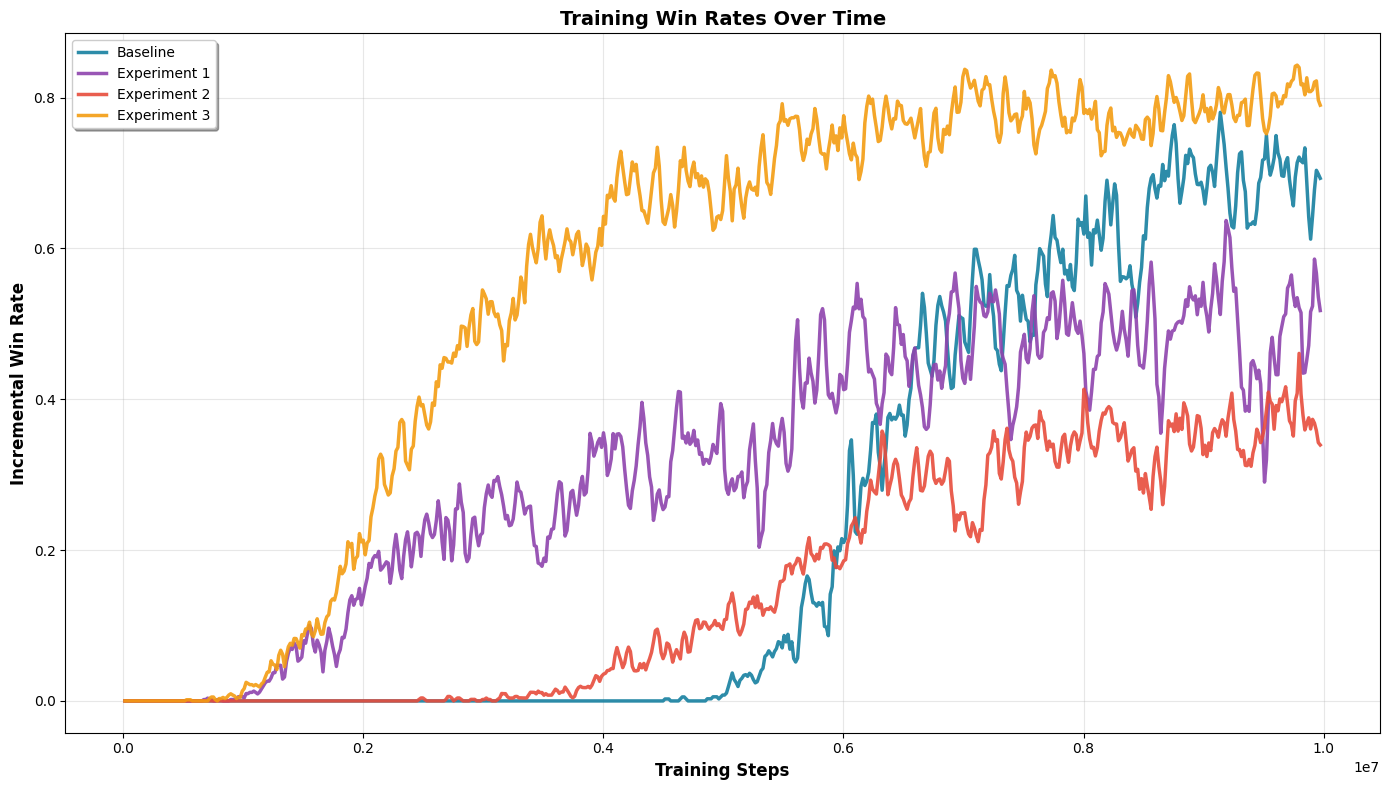

Training win rates plot saved!


In [ ]:
# Plot training win rates over time with unified colors
fig, ax = plt.subplots(figsize=(14, 8))

# Define the order of experiments to match the color scheme
experiment_order = ['Baseline', 'Experiment 1', 'Experiment 2', 'Experiment 3']

# Plot each experiment with its corresponding color
for i, exp_name in enumerate(experiment_order):
    if exp_name in training_df.columns:
        # Apply smoothing with sliding window of 3
        smoothed_data = training_df[exp_name].rolling(window=3, center=True).mean()
        ax.plot(training_df['Step'], smoothed_data, 
                color=EXPERIMENT_COLORS[i], linewidth=2.5, 
                label=exp_name, alpha=0.9)

# Customize the plot
ax.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
ax.set_ylabel('Incremental Win Rate', fontsize=12, fontweight='bold')
ax.set_title('Training Win Rates Over Time', fontsize=14, fontweight='bold')

# Add legend with experiment colors
ax.legend(loc='best', frameon=True, shadow=True)

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Format x-axis to show step numbers more clearly
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig('out/training_win_rates.pdf', format='pdf', dpi=300, bbox_inches='tight')

print("Training win rates plot saved!")

In [37]:
# Load and plot training win rate data with unified colors
# df_appendix = load_data('data/win_rate_training_cleaned.csv', 'incre_win_rate')

df_appendix= pd.read_csv('data/win_rate_training_cleaned.csv')
df_appendix.columns

metric_suffix = 'incre_win_rate'  # Define the metric suffix to filter columns
df_appendix = df_appendix.filter(regex=f'(Step)|({metric_suffix})$', axis=1)
print(df_appendix.columns)

df_appendix = df_appendix.rename(columns=lambda x: x.split(' - ')[0] if metric_suffix in x else x)
# Rename 'Experiment 0 (Original Version)' to Baseline
df_appendix = df_appendix.rename(columns=lambda x: 'Baseline' if x == 'Experiment 0 (Original Version)' else x)


if DROP_EXPERIMENT1:
    columns_to_drop = [col for col in df_appendix.columns if col.startswith('Experiment 1')]
    df_appendix = df_appendix.rename(columns=lambda x: "Experiment-A" if x.startswith('Experiment 1') else x)
    print(df_appendix.columns)
    # Rename experiment02 to experiment01, experiment03 to experiment02, etc.
    df_appendix = df_appendix.rename(columns=lambda x: f'Experiment {int(x[10:]) - 1}' if x.startswith('Experiment ') else x)
print(df_appendix.columns)

# SOrt the columns to ensure consistent order
df_appendix = df_appendix.reindex(sorted(df_appendix.columns), axis=1)

df_appendix

Index(['Step', 'Experiment 2 - incre_win_rate',
       'Experiment 1 - incre_win_rate', 'Experiment 4 - incre_win_rate',
       'Experiment 0 (Original Version) - incre_win_rate',
       'Experiment 3 - incre_win_rate'],
      dtype='object')
Index(['Step', 'Experiment 2', 'Experiment-A', 'Experiment 4', 'Baseline',
       'Experiment 3'],
      dtype='object')
Index(['Step', 'Experiment 1', 'Experiment-A', 'Experiment 3', 'Baseline',
       'Experiment 2'],
      dtype='object')


,Baseline,Experiment 1,Experiment 2,Experiment 3,Experiment-A,Step
0,0.000000,0.000000,0.000000,0.000000,0.000000,3200
1,0.000000,0.000000,0.000000,0.000000,0.000000,19200
2,0.000000,0.000000,0.000000,0.000000,0.000000,35200
3,0.000000,0.000000,0.000000,0.000000,0.000000,51200
4,0.000000,0.000000,0.000000,0.000000,0.000000,67200
...,...,...,...,...,...,...
620,0.693431,0.556962,0.393443,0.867925,0.693431,9923200
621,0.700000,0.614865,0.344633,0.792271,0.700000,9939200
622,0.717557,0.529801,0.336957,0.806604,0.717557,9955200
623,0.678571,0.462500,0.346154,0.791667,0.678571,9971200


Index(['Baseline', 'Experiment 1', 'Experiment 2', 'Experiment 3',
       'Experiment-A', 'Step'],
      dtype='object')


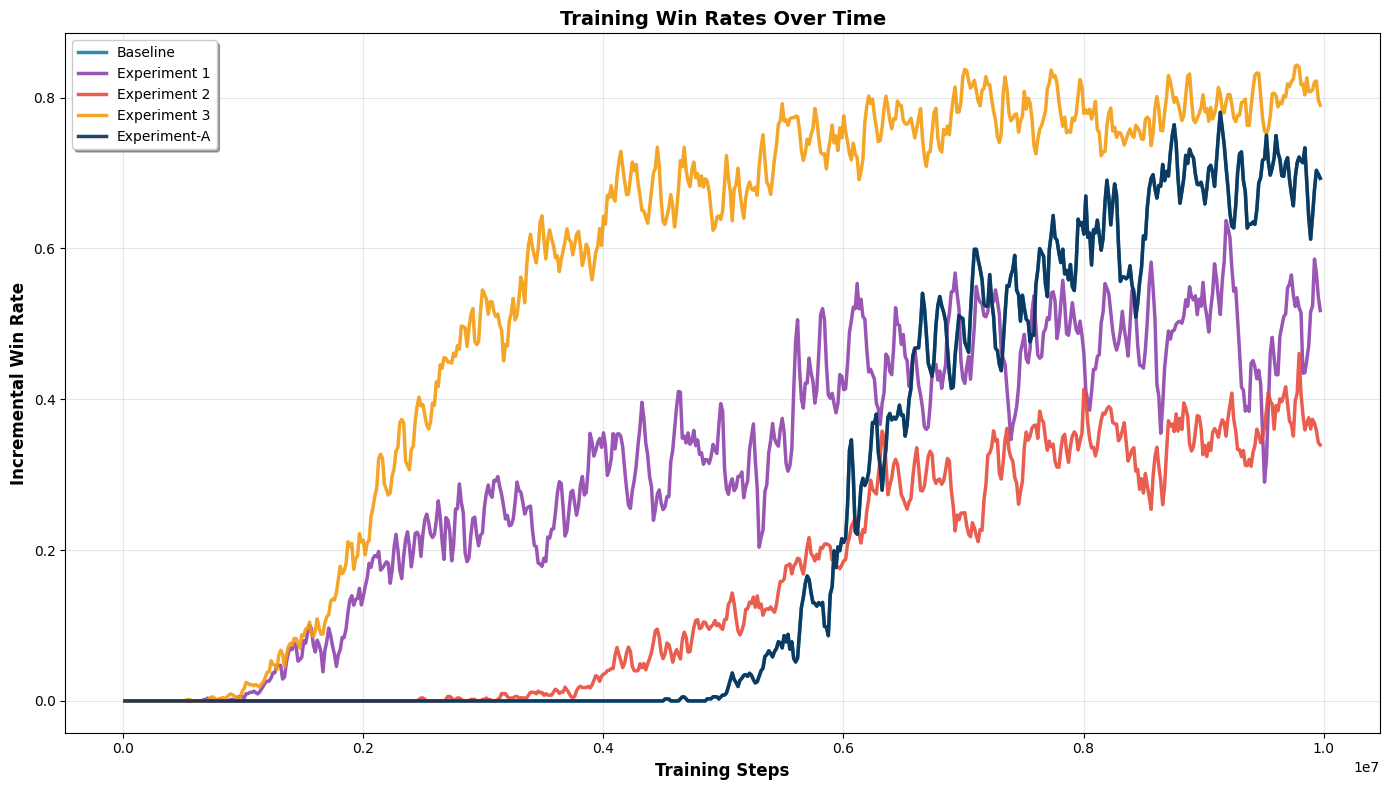

Training win rates plot saved!


In [43]:
# Plot training win rates over time with unified colors
fig, ax = plt.subplots(figsize=(14, 8))

# Define the order of experiments to match the color scheme
experiment_order = ['Baseline', 'Experiment 1', 'Experiment 2', 'Experiment 3', 'Experiment-A']
print(df_appendix.columns)

colors = [
        "#1680A0",  # Vibrant teal (Experiment 1)
        '#8E44AD',  # Rich purple (Experiment 3)
        '#E74C3C',  # Warm coral red (Experiment 2)
        '#F39C12',  # Golden amber (Experiment 4)
        "#08325C",  # Deep navy blue (Baseline)
    ]
# Plot each experiment with its corresponding color
for i, exp_name in enumerate(experiment_order):
    # Apply smoothing with sliding window of 3
    smoothed_data = df_appendix[exp_name].rolling(window=3, center=True).mean()
    ax.plot(df_appendix['Step'], smoothed_data, 
            color=colors[i], linewidth=2.5, 
            label=exp_name, alpha=0.9)

# Customize the plot
ax.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
ax.set_ylabel('Incremental Win Rate', fontsize=12, fontweight='bold')
ax.set_title('Training Win Rates Over Time', fontsize=14, fontweight='bold')

# Add legend with experiment colors
ax.legend(loc='best', frameon=True, shadow=True)

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Format x-axis to show step numbers more clearly
ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig('out/training_win_rates_appendix.pdf', format='pdf', dpi=300, bbox_inches='tight')

print("Training win rates plot saved!")

In [ ]:
# Plot both metrics with unified colors
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Get colors for each experiment
experiment_names = df.index.tolist()

for i, metric in enumerate(['Win Rate', 'Episode Rewards']):
    ax = axes[i]
    data = df[metric]
    
    # Plot with error bars using unified colors
    bars = ax.bar(range(len(data)), data['median'], yerr=data['std'], 
                  capsize=4, color=colors, alpha=0.8, 
                  edgecolor='white', linewidth=0.5)
    
    ax.set_title(f'Median Evaluation {metric} by Experiment', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    #set ylim
    ax.set_xticks(range(len(experiment_names)))
    ax.set_xticklabels(experiment_names, rotation=0, ha='center', fontsize=12)
    
    
    # Add values inside the bars using bar_label
    ax.bar_label(bars, labels=[f"{val:.2f}" for val in data['median']], 
                 label_type='center', fontsize=12, fontweight='bold', color='white')
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1)  # Adjusted for better visibility
# plt.tight_layout()
plt.show()

# Create output directory if it doesn't exist
import os
os.makedirs('out', exist_ok=True)

# Save the figure as pdf
fig.savefig('out/evaluation_results_split_appendix.pdf', format='pdf', dpi=300, bbox_inches='tight')

# Print the dataframe to console
print(df)